#  Candle Production Optimization - Linear Programming with PuLP

##  Problem Setup

A small candle-making business produces **two types of candles**:

- **Scented Candles**
- **Unscented Candles**

Each candle consumes **wax** and **labor hours**, both of which are limited. The business wants to **maximize profit** by deciding how many of each type to produce, within these resource constraints.

###  Given:

- **Profit:**
  - Scented = ₹5
  - Unscented = ₹3
- **Wax requirement:**
  - Scented = 3 units
  - Unscented = 2 units
- **Labor requirement:**
  - Scented = 2 hours
  - Unscented = 1 hour
- **Available Resources:**
  - 60 units of wax
  - 40 hours of labor

The objective is to determine the **optimal number of scented and unscented candles** to produce in order to **maximize total profit**.


In [5]:
from pulp import LpMaximize, LpProblem, LpVariable, value, LpStatus

# Define the LP problem
model = LpProblem("Candle_Profit_Maximization", LpMaximize)

# Decision Variables
x = LpVariable("Scented_Candles", lowBound=0, cat='Integer')
y = LpVariable("Unscented_Candles", lowBound=0, cat='Integer')

# Objective Function
model += 5 * x + 3 * y, "Total_Profit"

# Constraints
model += 3 * x + 2 * y <= 60, "Wax_Constraint"
model += 2 * x + 1 * y <= 40, "Labor_Constraint"

# Solve the Model
model.solve()

# Output Results
print("Status:", LpStatus[model.status])
print("Optimal Scented Candles:", x.varValue)
print("Optimal Unscented Candles:", y.varValue)
print("Maximum Profit: ₹", value(model.objective))


Status: Optimal
Optimal Scented Candles: 20.0
Optimal Unscented Candles: 0.0
Maximum Profit: ₹ 100.0


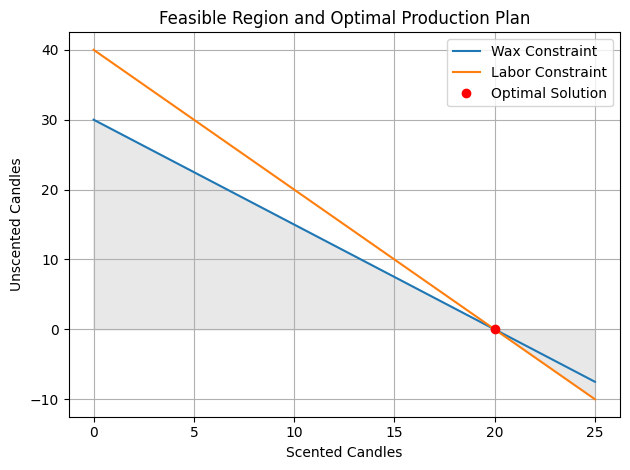

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Plot Constraints
x_vals = np.linspace(0, 25, 100)
wax_line = (60 - 3 * x_vals) / 2
labor_line = (40 - 2 * x_vals) / 1

plt.plot(x_vals, wax_line, label='Wax Constraint')
plt.plot(x_vals, labor_line, label='Labor Constraint')
plt.fill_between(x_vals, np.minimum(wax_line, labor_line), color='lightgray', alpha=0.5)

# Plot Optimal Point
plt.plot(x.varValue, y.varValue, 'ro', label='Optimal Solution')

plt.xlabel('Scented Candles')
plt.ylabel('Unscented Candles')
plt.title('Feasible Region and Optimal Production Plan')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
!pip install pulp